# Analyze GRPO Reward Learning

This notebook reads the GRPO trainer metrics log for a single run and plots the total reward and each reward component over optimization steps.

Primary target in this notebook:
- `experiments/checkpoints/grpo_staged_v2_stagebystage/grpo_log/train_metrics.jsonl`


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [6]:
train_metrics_path = Path('/u/chenyuen0103/ENCO/experiments/checkpoints/grpo_staged_v3_balanced_4gpu/grpo_log/train_metrics.jsonl')
output_dir = train_metrics_path.parent / 'reward_analysis'
output_dir.mkdir(parents=True, exist_ok=True)
if train_metrics_path.parent.parent.name == 'grpo':
    run_name = train_metrics_path.parent.parent.parent.name
else:
    run_name = train_metrics_path.parent.parent.name
assert train_metrics_path.exists(), train_metrics_path
train_metrics_path


PosixPath('/u/chenyuen0103/ENCO/experiments/checkpoints/grpo_staged_v3_balanced_4gpu/grpo_log/train_metrics.jsonl')

In [7]:
df = pd.read_json(train_metrics_path, lines=True)

# Keep only per-step training rows; the final trainer summary row has runtime stats but no reward columns.
df = df[df['global_step'].notna()].copy()
df = df.sort_values('global_step').drop_duplicates(subset=['global_step'], keep='first').reset_index(drop=True)

reward_mean_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/mean')]
reward_std_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/std')]
positive_reward_cols = [col for col in reward_mean_cols if df[col].fillna(0).abs().max() > 0]
zero_reward_cols = [col for col in reward_mean_cols if col not in positive_reward_cols]

print(f'run: {run_name}')
print(f'rows: {len(df)}')
print('reward mean columns:')
for col in reward_mean_cols:
    print('  ', col)

df.head()


run: grpo_staged_v3_balanced_4gpu
rows: 80
reward mean columns:
   rewards/cd_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_cot_structure_reward/mean
   rewards/cd_skeleton_f1_reward/mean
   rewards/cd_vstruct_f1_reward/mean
   rewards/cd_orientation_f1_reward/mean
   rewards/cd_graph_reward/mean


,global_step,epoch,time_unix,loss,grad_norm,learning_rate,num_tokens,completions/mean_length,completions/min_length,completions/max_length,completions/clipped_ratio,completions/mean_terminated_length,completions/min_terminated_length,completions/max_terminated_length,rewards/cd_format_reward/mean,rewards/cd_format_reward/std,rewards/cd_edge_f1_reward/mean,rewards/cd_edge_f1_reward/std,rewards/cd_low_shd_reward/mean,rewards/cd_low_shd_reward/std,rewards/cd_cot_structure_reward/mean,rewards/cd_cot_structure_reward/std,rewards/cd_skeleton_f1_reward/mean,rewards/cd_skeleton_f1_reward/std,rewards/cd_vstruct_f1_reward/mean,rewards/cd_vstruct_f1_reward/std,rewards/cd_orientation_f1_reward/mean,rewards/cd_orientation_f1_reward/std,rewards/cd_graph_reward/mean,rewards/cd_graph_reward/std,reward,reward_std,frac_reward_zero_std,kl,entropy,clip_ratio/low_mean,clip_ratio/low_min,clip_ratio/high_mean,clip_ratio/high_max,clip_ratio/region_mean
0,1,0.001333,1.776043e+09,0.0216,0.052490,0.000005,55949,6481.625,313,8192,0.500,4771.250000,313,7930,0.01250,0.023146,0.018750,0.034718,0.055000,0.076158,0.0,0.0,0,0,0,0,0,0,0.031250,0.057864,0.117500,0.158360,0.0,0.031927,0.452550,0,0,0,0,0
1,2,0.002667,1.776043e+09,0.1612,0.018677,0.000005,104048,5500.375,202,8192,0.625,1014.333374,202,2038,0.00000,0.000000,0.018750,0.053033,0.020000,0.056569,0.0,0.0,0,0,0,0,0,0,0.031250,0.088388,0.070000,0.140000,0.5,0.035542,0.306367,0,0,0,0,0
2,3,0.004000,1.776044e+09,0.0004,0.025391,0.000005,172389,8030.625,6912,8192,0.750,7546.500000,6912,8181,0.00625,0.017678,0.012500,0.035355,0.021429,0.060609,0.0,0.0,0,0,0,0,0,0,0.020833,0.058926,0.061012,0.122024,0.5,0.018005,0.415474,0,0,0,0,0
3,4,0.005333,1.776044e+09,-0.0690,0.029419,0.000005,234048,7195.375,219,8192,0.875,219.000000,219,219,0.00000,0.000000,0.000000,0.000000,0.020000,0.056569,0.0,0.0,0,0,0,0,0,0,0.000000,0.000000,0.020000,0.040000,0.5,0.039186,0.416237,0,0,0,0,0
4,5,0.006667,1.776045e+09,0.3316,0.038330,0.000005,286897,6094.125,463,8192,0.625,2597.666748,463,6529,0.00625,0.017678,0.028125,0.055802,0.056250,0.077816,0.0,0.0,0,0,0,0,0,0,0.046875,0.093003,0.137500,0.223016,0.0,0.035624,0.339049,0,0,0,0,0


In [8]:
summary_cols = [
    'global_step',
    'epoch',
    'reward',
    'reward_std',
    'frac_reward_zero_std',
    'completions/clipped_ratio',
    'kl',
    'entropy',
] + reward_mean_cols

df[summary_cols]


,global_step,epoch,reward,reward_std,frac_reward_zero_std,completions/clipped_ratio,kl,entropy,rewards/cd_format_reward/mean,rewards/cd_edge_f1_reward/mean,rewards/cd_low_shd_reward/mean,rewards/cd_cot_structure_reward/mean,rewards/cd_skeleton_f1_reward/mean,rewards/cd_vstruct_f1_reward/mean,rewards/cd_orientation_f1_reward/mean,rewards/cd_graph_reward/mean
0,1,0.001333,0.117500,0.158360,0.0,0.500,0.031927,0.452550,0.01250,0.018750,0.055000,0.0,0,0,0,0.031250
1,2,0.002667,0.070000,0.140000,0.5,0.625,0.035542,0.306367,0.00000,0.018750,0.020000,0.0,0,0,0,0.031250
2,3,0.004000,0.061012,0.122024,0.5,0.750,0.018005,0.415474,0.00625,0.012500,0.021429,0.0,0,0,0,0.020833
3,4,0.005333,0.020000,0.040000,0.5,0.875,0.039186,0.416237,0.00000,0.000000,0.020000,0.0,0,0,0,0.000000
4,5,0.006667,0.137500,0.223016,0.0,0.625,0.035624,0.339049,0.00625,0.028125,0.056250,0.0,0,0,0,0.046875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,0.101333,0.127500,0.115570,0.0,0.500,0.027448,0.484990,0.01250,0.018750,0.071250,0.0,0,0,0,0.025000
76,77,0.102667,0.140000,0.161658,0.5,0.625,0.037034,0.450071,0.00000,0.037500,0.040000,0.0,0,0,0,0.062500
77,78,0.104000,0.100714,0.158401,0.0,0.500,0.047215,0.393901,0.00000,0.015000,0.060714,0.0,0,0,0,0.025000
78,79,0.105333,0.078780,0.119431,0.0,0.625,0.017796,0.440989,0.00625,0.005000,0.059196,0.0,0,0,0,0.008333


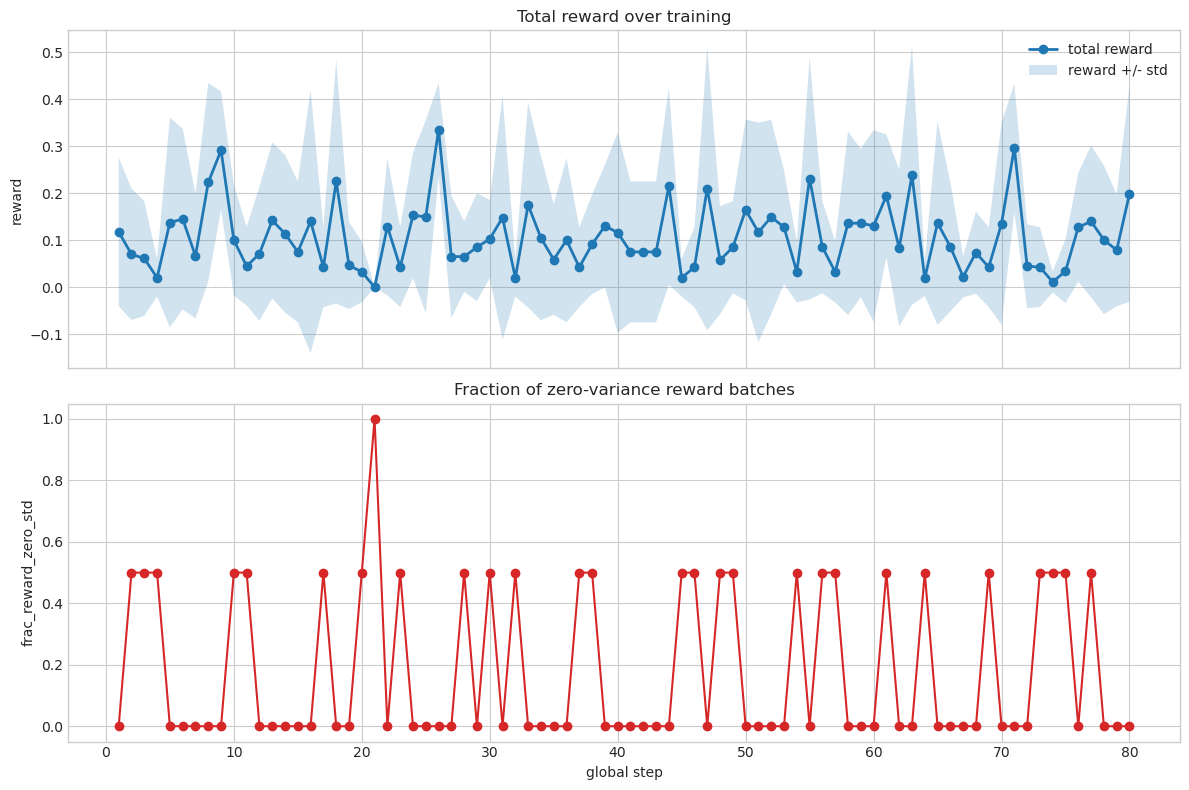

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['global_step'], df['reward'], marker='o', linewidth=2, label='total reward')
if 'reward_std' in df.columns:
    axes[0].fill_between(
        df['global_step'],
        df['reward'] - df['reward_std'],
        df['reward'] + df['reward_std'],
        alpha=0.2,
        label='reward +/- std',
    )
axes[0].set_ylabel('reward')
axes[0].set_title('Total reward over training')
axes[0].legend(loc='best')

axes[1].plot(df['global_step'], df['frac_reward_zero_std'], marker='o', color='tab:red')
axes[1].set_xlabel('global step')
axes[1].set_ylabel('frac_reward_zero_std')
axes[1].set_title('Fraction of zero-variance reward batches')

plt.tight_layout()
fig.savefig(output_dir / 'total_reward_and_zero_std.png', dpi=160, bbox_inches='tight')


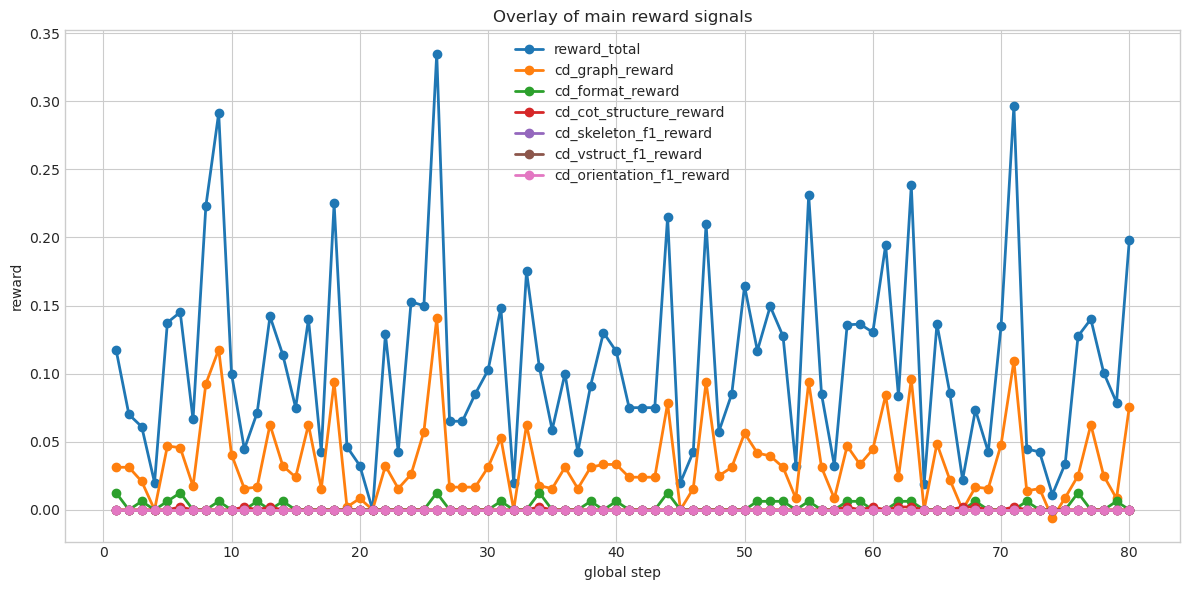

In [10]:
overlay_priority = [
    'reward',
    'rewards/length_penalty_reward/mean',
    'rewards/cd_graph_reward/mean',
    'rewards/cd_format_reward/mean',
    'rewards/cd_cot_structure_reward/mean',
    'rewards/cd_skeleton_f1_reward/mean',
    'rewards/cd_vstruct_f1_reward/mean',
    'rewards/cd_orientation_f1_reward/mean',
]
overlay_cols = [c for c in overlay_priority if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
for col in overlay_cols:
    label = 'reward_total' if col == 'reward' else col.removeprefix('rewards/').removesuffix('/mean')
    ax.plot(df['global_step'], df[col], marker='o', linewidth=2, label=label)

ax.set_xlabel('global step')
ax.set_ylabel('reward')
ax.set_title('Overlay of main reward signals')
ax.legend(loc='best')
plt.tight_layout()
fig.savefig(output_dir / 'main_reward_overlay.png', dpi=160, bbox_inches='tight')


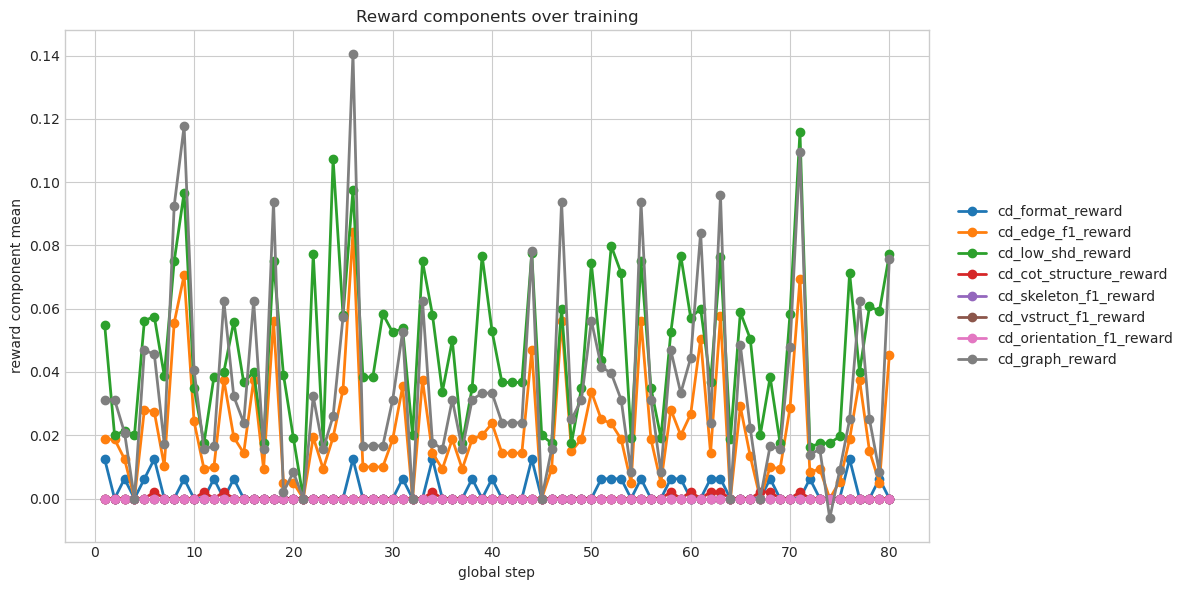

In [11]:
if reward_mean_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in reward_mean_cols:
        short = col.removeprefix('rewards/').removesuffix('/mean')
        ax.plot(df['global_step'], df[col], marker='o', linewidth=2, label=short)
    ax.set_xlabel('global step')
    ax.set_ylabel('reward component mean')
    ax.set_title('Reward components over training')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    fig.savefig(output_dir / 'all_reward_components.png', dpi=160, bbox_inches='tight')
else:
    print('No reward component mean columns found.')


In [12]:
positive_reward_cols = [col for col in reward_mean_cols if df[col].fillna(0).abs().max() > 0]
zero_reward_cols = [col for col in reward_mean_cols if col not in positive_reward_cols]

print('Reward components that moved:')
for col in positive_reward_cols:
    print('  ', col)

print('\nReward components that stayed at 0:')
for col in zero_reward_cols:
    print('  ', col)


Reward components that moved:
   rewards/cd_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_cot_structure_reward/mean
   rewards/cd_graph_reward/mean

Reward components that stayed at 0:
   rewards/cd_skeleton_f1_reward/mean
   rewards/cd_vstruct_f1_reward/mean
   rewards/cd_orientation_f1_reward/mean


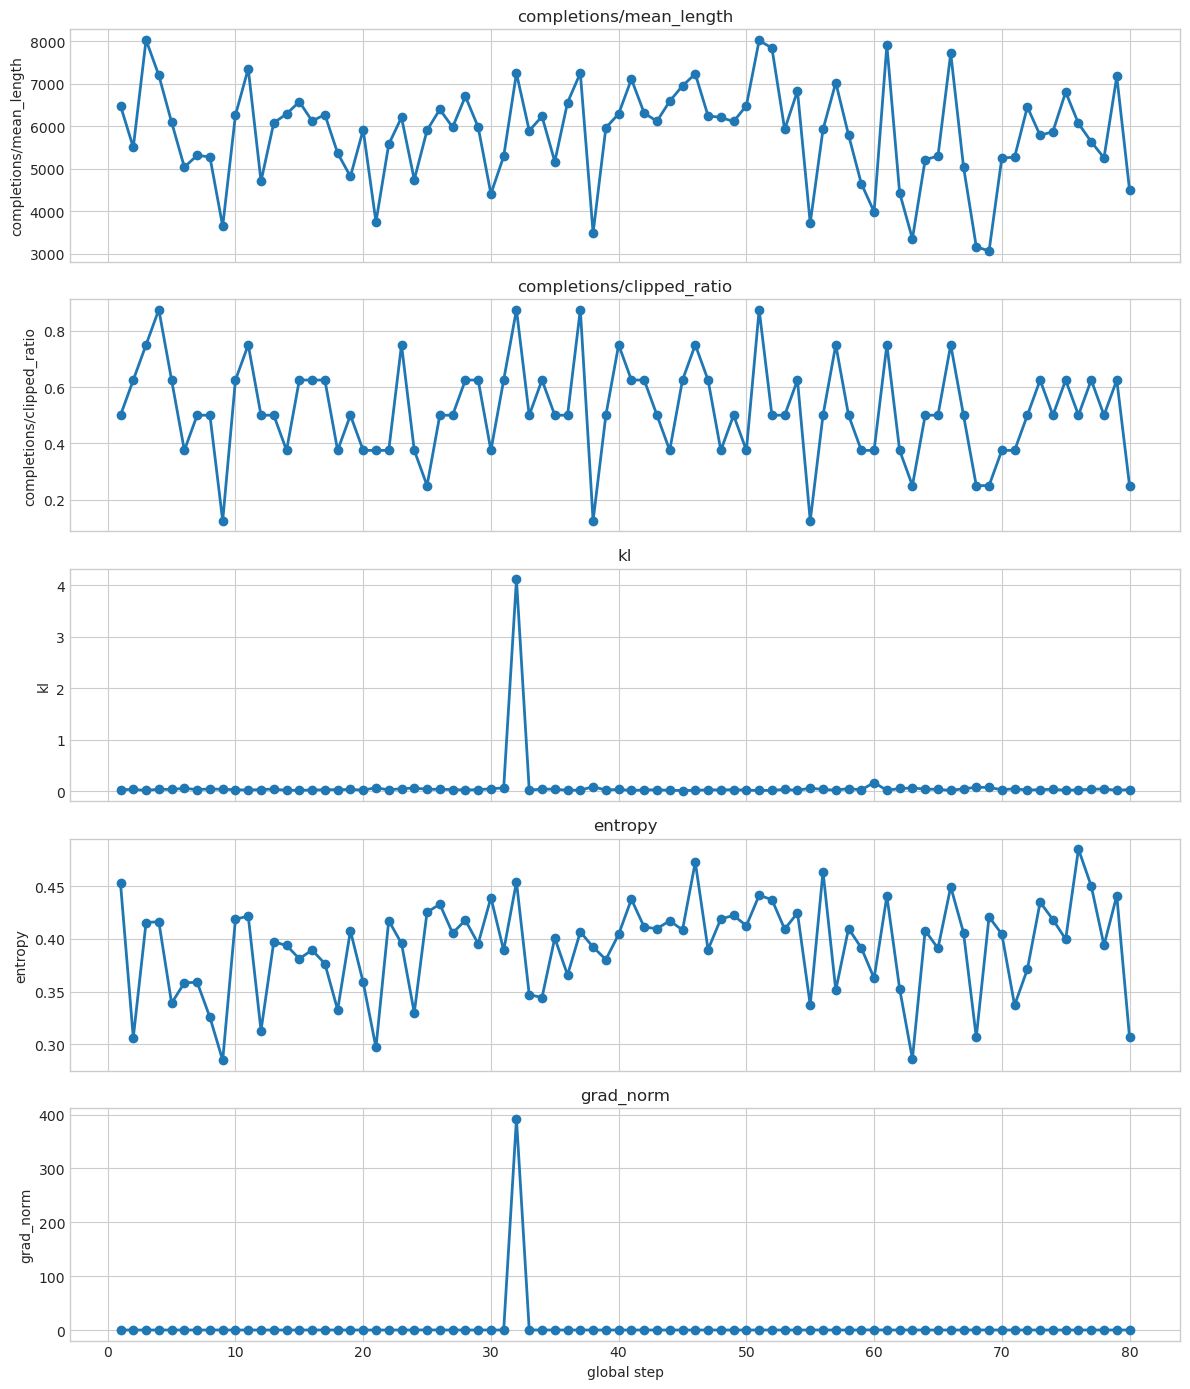

In [13]:
diagnostic_cols = [
    'completions/mean_length',
    'completions/clipped_ratio',
    'kl',
    'entropy',
    'grad_norm',
]

available_diagnostic_cols = [c for c in diagnostic_cols if c in df.columns]
n = len(available_diagnostic_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, available_diagnostic_cols):
    ax.plot(df['global_step'], df[col], marker='o', linewidth=2)
    ax.set_ylabel(col)
    ax.set_title(col)

axes[-1].set_xlabel('global step')
plt.tight_layout()
fig.savefig(output_dir / 'diagnostics.png', dpi=160, bbox_inches='tight')


In [14]:
display_cols = ['global_step', 'reward', 'reward_std', 'frac_reward_zero_std'] + positive_reward_cols
df[display_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
global_step,80.0,40.500000,23.237900,1.00000,20.750000,40.500000,60.250000,80.000000
reward,80.0,0.107252,0.070055,0.00000,0.054695,0.095625,0.140000,0.335000
reward_std,80.0,0.140345,0.065951,0.00000,0.086603,0.133254,0.192457,0.301658
frac_reward_zero_std,80.0,0.181250,0.254625,0.00000,0.000000,0.000000,0.500000,1.000000
rewards/cd_format_reward/mean,80.0,0.002422,0.003914,0.00000,0.000000,0.000000,0.006250,0.012500
rewards/cd_edge_f1_reward/mean,80.0,0.021882,0.018219,0.00000,0.009375,0.018750,0.028281,0.084375
rewards/cd_low_shd_reward/mean,80.0,0.046816,0.024614,0.00000,0.020000,0.040000,0.060000,0.115893
rewards/cd_cot_structure_reward/mean,80.0,0.000286,0.000722,0.00000,0.000000,0.000000,0.000000,0.002083
rewards/cd_graph_reward/mean,80.0,0.035846,0.030375,-0.00625,0.015625,0.028646,0.047135,0.140625


In [15]:
window = min(10, len(df))
summary = pd.Series({
    'steps': int(len(df)),
    'reward_mean': df['reward'].mean(),
    'reward_min': df['reward'].min(),
    'reward_max': df['reward'].max(),
    'reward_first_window_mean': df['reward'].head(window).mean(),
    'reward_last_window_mean': df['reward'].tail(window).mean(),
    'best_step': int(df.loc[df['reward'].idxmax(), 'global_step']),
    'best_step_reward': df['reward'].max(),
})
summary


steps                       80.000000
reward_mean                  0.107252
reward_min                   0.000000
reward_max                   0.335000
reward_first_window_mean     0.123187
reward_last_window_mean      0.107437
best_step                   26.000000
best_step_reward             0.335000
dtype: float64

In [16]:
top_cols = ['global_step', 'reward', 'reward_std', 'frac_reward_zero_std'] + positive_reward_cols
df.nlargest(min(10, len(df)), 'reward')[top_cols]


,global_step,reward,reward_std,frac_reward_zero_std,rewards/cd_format_reward/mean,rewards/cd_edge_f1_reward/mean,rewards/cd_low_shd_reward/mean,rewards/cd_cot_structure_reward/mean,rewards/cd_graph_reward/mean
25,26,0.335000,0.099434,0.0,0.01250,0.084375,0.097500,0.000000,0.140625
70,71,0.296726,0.136301,0.0,0.00000,0.069375,0.115893,0.002083,0.109375
8,9,0.291280,0.125388,0.0,0.00625,0.070625,0.096696,0.000000,0.117708
62,63,0.238155,0.275836,0.0,0.00625,0.057589,0.076250,0.002083,0.095982
54,55,0.231250,0.257358,0.0,0.00625,0.056250,0.075000,0.000000,0.093750
17,18,0.225000,0.259808,0.0,0.00000,0.056250,0.075000,0.000000,0.093750
7,8,0.223016,0.211203,0.0,0.00000,0.055506,0.075000,0.000000,0.092510
43,44,0.215000,0.210343,0.0,0.01250,0.046875,0.077500,0.000000,0.078125
46,47,0.210000,0.301658,0.0,0.00000,0.056250,0.060000,0.000000,0.093750
79,80,0.198254,0.229325,0.0,0.00000,0.045417,0.077143,0.000000,0.075694


In [17]:
saved_plots = sorted(str(path.relative_to(train_metrics_path.parent)) for path in output_dir.glob('*.png'))
saved_plots


['reward_analysis/all_reward_components.png',
 'reward_analysis/diagnostics.png',
 'reward_analysis/main_reward_overlay.png',
 'reward_analysis/total_reward_and_zero_std.png']

In [12]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/mixed_permuted_staged_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())

FileNotFoundError: [Errno 2] No such file or directory: '/u/chenyuen0103/ENCO/experiments/data/mixed_permuted_staged_sft.jsonl'

In [13]:
print(rows[0]['prompt'])

system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant reasons step by step inside <think> tags, following three explicit stages:
  Stage 1 (Skeleton): List each directly connected variable pair on its own line as "X -- Y". If none, write "None".
  Stage 2 (V-structures): List each unshielded collider as "(parent1, collider, parent2)" on its own line. If none, write "None".
  Stage 3 (Orientation): List each directed edge on its own line as "X -> Y". If none, write "None".
After reasoning, the assistant outputs the final adjacency matrix inside <answer> tags.
user
You are a question-answering assistant with knowledge of causal inference and causal discovery.
The following are empirical distributions computed from data sampled from an anonymized Bayesian network.
Infer the directed causal graph over the variables.

--- VARIABLES ---
0: X2
1: X8
2: X1
3: X3
4: X6
5: X7
6: X4
7: X5
--- ASSIGNMENT FORMAT ---
x = [X1,X2,X3,X4,X

In [14]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())
print(rows[0]['prompt'])

5300
dict_keys(['prompt', 'answer', 'source', 'graph', 'perm'])
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant reasons step by step inside <think> tags, following three explicit stages:
  Stage 1 (Skeleton): List each directly connected variable pair on its own line as "X -- Y". If none, write "None".
  Stage 2 (V-structures): List each unshielded collider as "(parent1, collider, parent2)" on its own line. If none, write "None".
  Stage 3 (Orientation): List each directed edge on its own line as "X -> Y". If none, write "None".
After reasoning, the assistant outputs the final adjacency matrix inside <answer> tags. The adjacency matrix is an N×N array of integers (0 or 1) in the order variables are listed under VARIABLES. Entry [i][j]=1 means variable i directly causes variable j; [i][j]=0 means no direct edge. Must be a DAG (acyclic).
user
You are a question-answering assistant with knowledge of causal inference an

In [15]:
print(rows[0]['answer'])

Stage 1 (Skeleton):
X1 -- X3
X1 -- X5
X2 -- X5
X2 -- X8
X4 -- X7
X4 -- X8
X5 -- X6
X5 -- X7

Stage 2 (V-structures):
(X5, X2, X8)
(X1, X5, X7)

Stage 3 (Orientation):
X1 -> X5
X3 -> X1
X4 -> X7
X4 -> X8
X5 -> X2
X5 -> X6
X7 -> X5
X8 -> X2</think><answer>{"adjacency_matrix": [[0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1], [0, 1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0]]}</answer>


In [16]:
import json
import re
from itertools import combinations

path = "/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(f"Total records: {len(rows)}")

# ── Regexes ──────────────────────────────────────────────────────────────────
VAR_BLOCK_RE  = re.compile(r"--- VARIABLES ---\n(.*?)\n---", re.DOTALL)
VAR_LINE_RE   = re.compile(r"^\s*(\d+)\s*:\s*(\S+)", re.MULTILINE)
INT_KEY_RE    = re.compile(r"do\((\w+)=(\d+)\)")
ANSWER_RE     = re.compile(r"<answer>(.*?)</answer>", re.DOTALL)
STAGE1_RE     = re.compile(r"Stage 1 \(Skeleton\):\n(.*?)(?=\n\nStage|\Z)", re.DOTALL)
STAGE3_RE     = re.compile(r"Stage 3 \(Orientation\):\n(.*?)(?=</think>|\Z)", re.DOTALL)
INT_BLOCK_RE  = re.compile(r"interventional_data=\{(.*?)\}\s*\n---", re.DOTALL)

errors = []

for idx, row in enumerate(rows):
    prompt = row["prompt"]
    answer = row["answer"]

    # 1. VARIABLES block is sequential X1..Xn
    var_m = VAR_BLOCK_RE.search(prompt)
    if not var_m:
        errors.append(f"[{idx}] missing VARIABLES block")
        continue
    var_lines = VAR_LINE_RE.findall(var_m.group(1))  # [(pos, name), ...]
    for pos, name in var_lines:
        expected = f"X{int(pos)+1}"
        if name != expected:
            errors.append(f"[{idx}] VARIABLES pos {pos} is '{name}', expected '{expected}'")

    n = len(var_lines)

    # 2. Interventional keys use sequential Xi labels
    int_m = INT_BLOCK_RE.search(prompt)
    if int_m:
        for key_var, key_val in INT_KEY_RE.findall(int_m.group(1)):
            # key_var should be X1..Xn
            if not re.match(r"^X\d+$", key_var):
                errors.append(f"[{idx}] non-sequential int key: do({key_var}={key_val})")
            else:
                xi = int(key_var[1:])
                if xi < 1 or xi > n:
                    errors.append(f"[{idx}] int key {key_var} out of range [X1..X{n}]")

    # 3. Parse adjacency matrix from answer
    ans_m = ANSWER_RE.search(answer)
    if not ans_m:
        errors.append(f"[{idx}] missing <answer> block")
        continue
    try:
        adj = json.loads(ans_m.group(1))["adjacency_matrix"]
    except Exception as e:
        errors.append(f"[{idx}] failed to parse adj: {e}")
        continue

    # 4. Adj is NxN binary integers
    if len(adj) != n:
        errors.append(f"[{idx}] adj rows={len(adj)}, expected {n}")
    for i, row_vals in enumerate(adj):
        if len(row_vals) != n:
            errors.append(f"[{idx}] adj row {i} has {len(row_vals)} cols, expected {n}")
        for j, v in enumerate(row_vals):
            if not isinstance(v, int) or v not in (0, 1):
                errors.append(f"[{idx}] adj[{i}][{j}]={v!r} is not 0/1 int")

    # 5. Stage 3 directed edges match adjacency matrix
    s3_m = STAGE3_RE.search(answer)
    if s3_m:
        s3_text = s3_m.group(1).strip()
        stage3_edges = set()
        if s3_text != "None":
            for line in s3_text.splitlines():
                m = re.match(r"(X\d+)\s*->\s*(X\d+)", line.strip())
                if m:
                    i, j = int(m.group(1)[1:]) - 1, int(m.group(2)[1:]) - 1
                    stage3_edges.add((i, j))
        adj_edges = {(i, j) for i in range(n) for j in range(n) if adj[i][j] == 1}
        if stage3_edges != adj_edges:
            errors.append(f"[{idx}] Stage 3 edges {stage3_edges} != adj edges {adj_edges}")

    # 6. Stage 1 skeleton matches adj (undirected)
    s1_m = STAGE1_RE.search(answer)
    if s1_m:
        s1_text = s1_m.group(1).strip()
        stage1_edges = set()
        if s1_text != "None":
            for line in s1_text.splitlines():
                m = re.match(r"(X\d+)\s*--\s*(X\d+)", line.strip())
                if m:
                    i, j = int(m.group(1)[1:]) - 1, int(m.group(2)[1:]) - 1
                    stage1_edges.add(frozenset([i, j]))
        adj_skel = {frozenset([i, j])
                    for i in range(n) for j in range(i+1, n)
                    if adj[i][j] or adj[j][i]}
        if stage1_edges != adj_skel:
            errors.append(f"[{idx}] Stage 1 skeleton mismatch")

print(f"\nChecked {len(rows)} records")
if errors:
    print(f"ERRORS ({len(errors)}):")
    for e in errors[:20]:
        print(" ", e)
else:
    print("All checks passed ✓")


Total records: 5300

Checked 5300 records
All checks passed ✓


In [ ]:
import json, random
from pathlib import Path
from collections import defaultdict

path = Path("./data/permuted_sft.jsonl")
with open(path) as f:
    rows = [json.loads(l) for l in f if l.strip()]

# Group by graph
by_graph = defaultdict(list)
for r in rows:
    by_graph[r["graph"]].append(r)

rng = random.Random(42)

train, val, test = [], [], []

for graph, records in by_graph.items():
    rng.shuffle(records)
    if graph == "sachs":
        split = int(0.2 * len(records))
        val  += records[:split]
        test += records[split:]
    else:
        train += records

rng.shuffle(train)
rng.shuffle(val)

out = Path("./data")
for name, split in [("sft_train", train), ("sft_val", val), ("sft_test", test)]:
    p = out / f"{name}.jsonl"
    with open(p, "w") as f:
        for r in split:
            f.write(json.dumps(r) + "\n")
    print(f"{name}: {len(split)} records → {p}")


sft_train: 2800 records → data/sft_train.jsonl
sft_val: 500 records → data/sft_val.jsonl
sft_test: 2000 records → data/sft_test.jsonl


In [21]:
import json
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B-Thinking-2507")

splits = {
    "train": train,
    "val":   val,
    "test":  test,
}

for split_name, records in splits.items():
    lengths = [
        len(tok(r["prompt"] + r["answer"], add_special_tokens=False).input_ids)
        for r in records
    ]
    lengths.sort()
    n = len(lengths)
    print(f"\n{split_name} ({n} records)")
    print(f"  min    = {lengths[0]}")
    print(f"  p25    = {lengths[n//4]}")
    print(f"  median = {lengths[n//2]}")
    print(f"  p75    = {lengths[3*n//4]}")
    print(f"  p90    = {lengths[int(n*0.90)]}")
    print(f"  p95    = {lengths[int(n*0.95)]}")
    print(f"  p99    = {lengths[int(n*0.99)]}")
    print(f"  max    = {lengths[-1]}")
    print(f"  > 3000 = {sum(l > 3000 for l in lengths)} ({100*sum(l>3000 for l in lengths)/n:.1f}%)")
    print(f"  > 8192 = {sum(l > 8192 for l in lengths)} ({100*sum(l>8192 for l in lengths)/n:.1f}%)")



train (2800 records)
  min    = 1611
  p25    = 4341
  median = 4364
  p75    = 4407
  p90    = 4555
  p95    = 4555
  p99    = 4555
  max    = 4555
  > 3000 = 2500 (89.3%)
  > 8192 = 0 (0.0%)

val (500 records)
  min    = 13539
  p25    = 13736
  median = 14280
  p75    = 14352
  p90    = 14496
  p95    = 14500
  p99    = 14504
  max    = 14508
  > 3000 = 500 (100.0%)
  > 8192 = 500 (100.0%)

test (2000 records)
  min    = 13539
  p25    = 13738
  median = 14282
  p75    = 14352
  p90    = 14496
  p95    = 14500
  p99    = 14504
  max    = 14508
  > 3000 = 2000 (100.0%)
  > 8192 = 2000 (100.0%)


In [32]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/descendant_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())
print(rows[0]['prompt'])

33000
dict_keys(['prompt', 'answer', 'graph', 'source', 'target', 'n_descendants'])
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant is an expert in causal inference and reasons from empirical evidence to identify causal relationships.
user
TASK: For the intervention do(X7 = 1), identify which variables are descendants of X7.
The following are empirical summaries from an anonymized Bayesian network.
ASSUMPTIONS:
- The true graph is a DAG (no directed cycles).
- Interventions are perfect do-interventions (surgical): do(X=v) cuts all incoming edges into X.
- Only descendants of the intervened variable can change because of the intervention, up to sampling noise.

--- INTERVENTION SEMANTICS ---
- In do(X7 = 1), X7 is externally fixed.
- The intervention removes all incoming edges into X7.
- Downstream variables may change; upstream variables should not change because of this intervention.

--- VARIABLE ORDER ---
0: X1 s

In [31]:
import json
from collections import Counter

path = "/u/chenyuen0103/ENCO/experiments/data/descendant_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

graph_counts = Counter(row["graph"] for row in rows)

print(len(rows))
print(graph_counts)

33000
Counter({'sachs': 15720, 'asia': 7680, 'earthquake': 4800, 'cancer': 4800})


In [26]:
import json, random

with open("./data/descendant_sft.jsonl") as f:
    recs = [json.loads(l) for l in f]

train = [r for r in recs if r["graph"] in {"cancer", "earthquake", "asia"}]
sachs = [r for r in recs if r["graph"] == "sachs"]

rng = random.Random(42)
rng.shuffle(sachs)
mid = len(sachs) // 2
val, test = sachs[:mid], sachs[mid:]

rng.shuffle(train)

for split, path in [(train, "./data/desc_sft_train.jsonl"),
                    (val,   "./data/desc_sft_val.jsonl"),
                    (test,  "./data/desc_sft_test.jsonl")]:
    with open(path, "w") as f:
        for r in split:
            f.write(json.dumps(r) + "\n")
    print(f"{path}: {len(split)} records")


./data/desc_sft_train.jsonl: 17280 records
./data/desc_sft_val.jsonl: 7860 records
./data/desc_sft_test.jsonl: 7860 records


In [27]:
import json
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B-Thinking-2507")

splits = {
    "train": train,
    "val":   val,
    "test":  test,
}

for split_name, records in splits.items():
    lengths = [
        len(tok(r["prompt"] + r["answer"], add_special_tokens=False).input_ids)
        for r in records
    ]
    lengths.sort()
    n = len(lengths)
    print(f"\n{split_name} ({n} records)")
    print(f"  min    = {lengths[0]}")
    print(f"  p25    = {lengths[n//4]}")
    print(f"  median = {lengths[n//2]}")
    print(f"  p75    = {lengths[3*n//4]}")
    print(f"  p90    = {lengths[int(n*0.90)]}")
    print(f"  p95    = {lengths[int(n*0.95)]}")
    print(f"  p99    = {lengths[int(n*0.99)]}")
    print(f"  max    = {lengths[-1]}")
    print(f"  > 3000 = {sum(l > 3000 for l in lengths)} ({100*sum(l>3000 for l in lengths)/n:.1f}%)")
    print(f"  > 8192 = {sum(l > 8192 for l in lengths)} ({100*sum(l>8192 for l in lengths)/n:.1f}%)")



train (17280 records)
  min    = 797
  p25    = 829
  median = 865
  p75    = 1073
  p90    = 1101
  p95    = 1132
  p99    = 1152
  max    = 1152
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)

val (7860 records)
  min    = 1417
  p25    = 1450
  median = 1526
  p75    = 1596
  p90    = 1613
  p95    = 1620
  p99    = 1631
  max    = 1639
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)

test (7860 records)
  min    = 1417
  p25    = 1450
  median = 1527
  p75    = 1597
  p90    = 1614
  p95    = 1621
  p99    = 1631
  max    = 1639
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)


In [21]:

import pandas as pd
from transformers import AutoTokenizer
import sys
sys.path.insert(0, "experiments")
from cd_training_format import canonicalize_cd_prompt

# Match the settings from the launch command
# MODEL = "./checkpoints/mixed_staged_sft_v2"
MODEL = "Qwen/Qwen3-4B-Thinking-2507"
CSV   = "./data/cancer_randcol_seed43.csv"
TASK  = "causal_discovery"

tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=True)

df = pd.read_csv(CSV)
raw = str(df.iloc[0]["prompt"])
prompt = canonicalize_cd_prompt(
    raw,
    task=TASK,
    wrap_system_prompt=True,
    append_format_hint=True,
    format_hint_text="",
    prefill_think=True,
)

ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
decoded = tokenizer.decode(ids)  # keeps special tokens

print(f"\n[DEBUG] Token count: {len(ids)}")
print(f"[DEBUG] Last 500 chars of decoded:\n{decoded[-500:]}")
print(f"\n[DEBUG] First 500 chars of decoded:\n{decoded[:500]}")




[DEBUG] Token count: 1821
[DEBUG] Last 500 chars of decoded:
0,1.0]]}
}
Output: <think>[staged reasoning]</think><answer>{"adjacency_matrix": ...}</answer>
"adjacency_matrix": N×N 0/1 matrix in variable order. Must be a DAG.

Formatting requirement: Reason in three stages inside <think>: Stage 1 (Skeleton) - one "X -- Y" per line; Stage 2 (V-structures) - one "(parent1, collider, parent2)" per line; Stage 3 (Orientation) - one "X -> Y" per line. Write "None" for any empty stage. Then output: <answer>{"adjacency_matrix": [...]}</answer>.
assistant
<think>


[DEBUG] First 500 chars of decoded:
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant reasons step by step inside <think> tags, following three explicit stages:
  Stage 1 (Skeleton): List each directly connected variable pair on its own line as "X -- Y". If none, write "None".
  Stage 2 (V-structures): List each unshielded collider as "(parent1, collider, parent2)"

In [2]:
import json
import csv

def jsonl_to_csv(jsonl_path, csv_path):
    """Convert JSONL to CSV format matching the target structure."""
    
    with open(jsonl_path, 'r') as f_in, open(csv_path, 'w', newline='') as f_out:
        fieldnames = [
            'dataset', 'bif_file', 'prompt_style', 'anonymize', 'obs_per_prompt',
            'int_per_combo', 'data_idx', 'shuffle_idx', 'given_edges', 'prompt_text', 'answer'
        ]
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()
        
        for idx, line in enumerate(f_in):
            record = json.loads(line)
            
            # Extract graph name from source (e.g., "cancer_obs100_int10_anon_train" -> "cancer")
            source = record.get('source', '')
            dataset = source.split('_')[0] if source else record.get('graph', '')
            
            row = {
                'dataset': dataset,
                'bif_file': '',  # Not available in JSONL
                'prompt_style': 'step_by_step',  # Inferred from prompt structure
                'anonymize': 1,  # Default
                'obs_per_prompt': 100,  # Extract from prompt if possible
                'int_per_combo': 10,
                'data_idx': idx,
                'shuffle_idx': idx,
                'given_edges': '',
                'prompt_text': record.get('prompt', ''),
                'answer': record.get('answer', '')
            }
            writer.writerow(row)

# Usage with absolute paths
jsonl_to_csv('/u/chenyuen0103/ENCO/experiments/data/grpo_cancer_eq_seed99.jsonl', 
             '/u/chenyuen0103/ENCO/experiments/data/grpo_cancer_eq_seed99.csv')